#**Projekt 3: Analiza danych i modelowanie regresyjne z obsługą wartości odstających**

Dane: `data.csv` (plik udostępniony przez prowadzącego).

Celem projektu jest przeprowadzenie eksploracji danych, obsługi
wartości odstających oraz budowa modelu regresyjnego w celu
przewidywania dochodu (Income) na podstawie dostarczonych
danych. Plik data.csv zawiera szczegółowe informacje finansowe i
demograficzne dotyczące 20 000 osób w Indiach. Obejmuje miesięczny
dochód, wydatki, cele oszczędnościowe oraz potencjalne oszczędności w
różnych kategoriach, takich jak artykuły spożywcze, transport, opieka
zdrowotna i inne.

Wykonaj następujące polecenia:
##1. Wczytaj plik `data.csv` i wyświetl podstawowe informacje o danych (`head()`, `info()`).
   - zidentyfikuj braki danych,
   - uzupełnij braki w kolumnach liczbowych (np. medianą),
   - uzupełnij braki w kolumnach kategorycznych (np. najczęstszą wartością) lub usuń wiersze z brakami.

In [ ]:
from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

In [ ]:
uploaded = files.upload()

Saving data.csv to data.csv


In [ ]:
df = pd.read_csv("data.csv")

In [ ]:
df.head()

,Age,City_Tier,Education,Sector,Marital_Status,Dependents,Income,Rent,Groceries,Transport,Healthcare,Entertainment,Loan_Repayment,Savings_Goal,Potential_Savings
0,22,3,HS,Retail,Single,1,13770.50,3018.06,1730.99,966.41,792.45,1034.01,0.00,2391.27,6228.57
1,55,3,Bachelor,Manufacturing,Single,0,36753.63,10421.89,2567.12,3167.29,NaN,1873.98,4838.20,5529.53,12803.02
2,49,1,PhD,Healthcare,Married,2,69990.94,19913.46,8871.08,3554.88,1741.72,1863.42,0.00,11611.16,34046.38
3,39,1,HS,IT,Single,0,38720.32,9890.31,2186.69,1799.49,2139.95,1679.39,3167.76,5002.30,17856.73
4,38,2,HS,Healthcare,Single,4,30723.43,6653.45,3342.27,1302.85,1776.34,587.80,0.00,2879.97,17060.72


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                20000 non-null  int64  
 1   City_Tier          20000 non-null  int64  
 2   Education          19637 non-null  object 
 3   Sector             19600 non-null  object 
 4   Marital_Status     20000 non-null  object 
 5   Dependents         20000 non-null  int64  
 6   Income             20000 non-null  float64
 7   Rent               19593 non-null  float64
 8   Groceries          20000 non-null  float64
 9   Transport          20000 non-null  float64
 10  Healthcare         19609 non-null  float64
 11  Entertainment      20000 non-null  float64
 12  Loan_Repayment     19598 non-null  float64
 13  Savings_Goal       20000 non-null  float64
 14  Potential_Savings  20000 non-null  float64
dtypes: float64(9), int64(3), object(3)
memory usage: 2.3+ MB


In [ ]:
print(df.isnull().sum()[df.isnull().sum() > 0])

Education         363
Sector            400
Rent              407
Healthcare        391
Loan_Repayment    402
dtype: int64


In [ ]:
num_cols = df.select_dtypes(include=["number"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

In [ ]:
for col in num_cols:
  if df[col].isnull().any():
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)

In [ ]:
for col in cat_cols:
  if df[col].isnull().any():
    mode_value = df[col].mode()[0]
    df[col] = df[col].fillna(mode_value)

In [ ]:
print(df.isnull().sum().sum())

0


Pierwszym etapem projektu było wczytanie zbioru danych `data.csv` oraz przeprowadzenie wstępnej inspekcji jego struktury.

Charakterystyka zbioru:

* **Liczba rekordów:** 20 000
* **Liczba kolumn:** 15
* **Typy danych:** Zbiór zawiera zarówno zmienne numeryczne (np. `Age`, `Income`, `Rent`), jak i kategoryczne (np. `Education`, `Sector`, `Marital_Status`).

Identyfikacja braków danych:

Podczas analizy wykryte zostały braki danych w następujących kolumnach:
* `Education`: 363 braki
* `Sector`: 400 braków
* `Rent`: 407 braków
* `Healthcare`: 391 braków
* `Loan_Repayment`: 402 braki

Strategia uzupełniania braków:

Aby nie tracić cennych informacji zawartych w pozostałych kolumnach, zdecydowałam się na uzupełnienie braków zamiast usuwania wierszy:
*  **Kolumny liczbowe (`Rent`, `Healthcare`, `Loan_Repayment`):** Braki zostały uzupełnione **medianą**. Wybrałam medianę, ponieważ jest ona odporna na potencjalne wartości odstające w tych kolumnach.
*  **Kolumny kategoryczne (`Education`, `Sector`):** Braki uzupełniłam **modą**. Pozwala to na zachowanie najbardziej prawdopodobnej struktury danych dla zmiennych tekstowych.



##2. Zbadaj rozkład zmiennej `Income`:
   - wykonaj histogram (z opcjonalną linią gęstości),
   - wykonaj wykres pudełkowy.

In [ ]:
df.describe()

,Age,City_Tier,Dependents,Income,Rent,Groceries,Transport,Healthcare,Entertainment,Loan_Repayment,Savings_Goal,Potential_Savings
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,41.334500,2.057600,1.204050,40016.681768,8454.419927,3839.983238,2309.202759,1542.379235,1938.626373,1714.273319,4616.669084,20169.595918
std,13.832313,0.742435,1.168838,23782.207199,3973.901345,1854.421507,1169.288007,960.176597,1375.949000,2534.874993,2639.695573,19974.883431
min,18.000000,1.000000,0.000000,8000.000000,1000.000000,800.000000,300.000000,200.000000,0.000000,0.000000,0.000000,2557.520000
25%,29.000000,2.000000,0.000000,28233.035000,5641.027500,2522.760000,1472.385000,857.375000,963.625000,0.000000,2739.467500,12789.342500
50%,41.000000,2.000000,1.000000,36391.145000,7770.130000,3535.335000,2109.625000,1379.750000,1712.360000,0.000000,4160.880000,17271.060000
75%,53.000000,3.000000,2.000000,46604.807500,10534.580000,4810.050000,2919.740000,2033.352500,2649.070000,3124.955000,6014.767500,23030.220000
max,65.000000,3.000000,4.000000,541028.280000,43012.570000,20050.080000,10682.790000,7485.480000,13692.430000,25606.080000,23257.410000,503010.690000


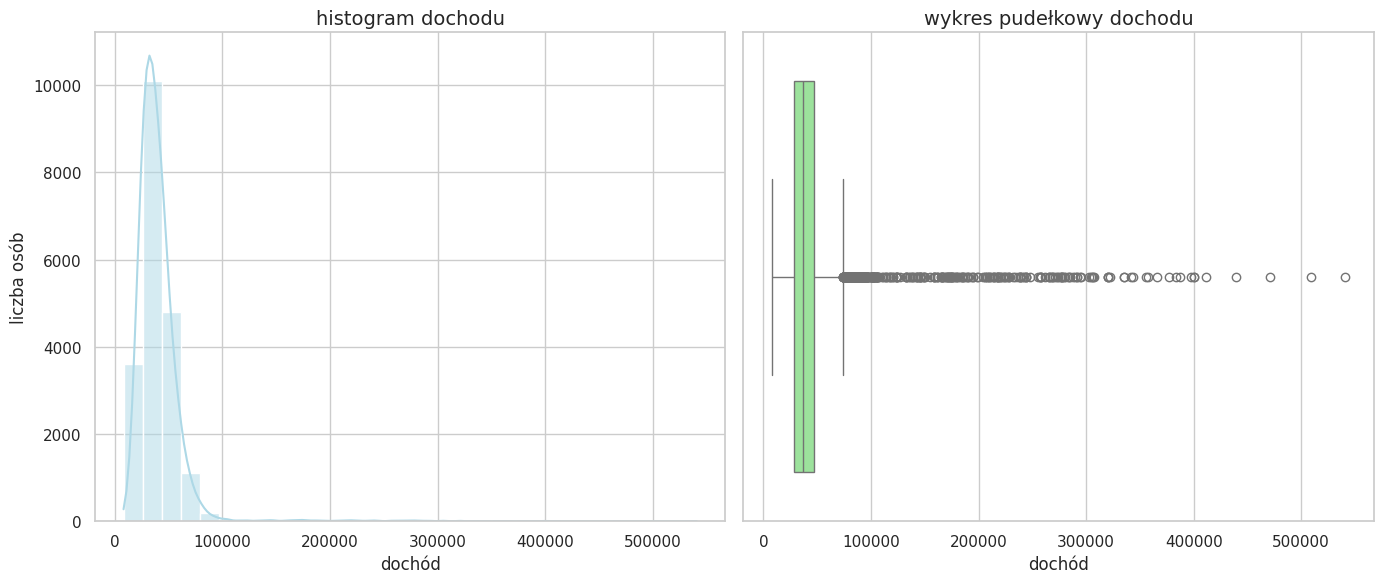

In [ ]:
sns.set(style="whitegrid")
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.histplot(df["Income"], kde=True, color="lightblue", bins=30)
plt.title("histogram dochodu", fontsize=14)
plt.xlabel("dochód", fontsize=12)
plt.ylabel("liczba osób", fontsize=12)
plt.subplot(1, 2, 2)
sns.boxplot(x=df["Income"], color="lightgreen")
plt.title("wykres pudełkowy dochodu", fontsize=14)
plt.xlabel("dochód", fontsize=12)
plt.tight_layout()
plt.show()

Kolejnym etapem była analiza rozkładu głównej zmiennej objaśnianej – `Income`. Wykorzystane zostały do tego dwie techniki wizualizacji: histogram oraz wykres pudełkowy.

Interpretacja wyników:

* **Histogram:** Wykres wskazuje na silną **asymetrię prawostronną** (dodatnią). Większość obserwacji koncentruje się w przedziale od 20 000 do 60 000, wykres ciągnie się w stronę bardzo wysokich wartości.
* **Linia gęstości:** Potwierdza, że rozkład nie jest normalny. Występuje wyraźne skupienie wokół mody, a następnie gwałtowny spadek liczebności dla wyższych dochodów.
* **Wykres pudełkowy (Boxplot):** Jest to kluczowe narzędzie do identyfikacji wartości odstających. Na wykresie widzimy bardzo dużą liczbę punktów znajdujących się poza "górnym wąsem". Niektóre z tych wartości są ekstremalnie wysokie (powyżej 500 000), co znacząco odbiega od reszty populacji.

Statystyki opisowe:
* **Średnia** jest wyraźnie wyższa od **mediany**. Taka relacja jest typowa dla rozkładów o asymetrii prawostronnej i sugeruje, że nieliczne, bardzo wysokie zarobki zawyżają średni wynik.
* **Współczynnik skośności** potwierdza bardzo silną asymetrię rozkładu.

**Wniosek:** Rozkład dochodów jest mocno zniekształcony przez wartości ekstremalne.

##3. Zidentyfikuj wartości odstające w `Income` metodą IQR:
   - wyznacz dolną i górną granicę IQR,
   - oznacz obserwacje odstające (np. kolumna `Income_Outlier` z wartościami `0/1`),
   - porównaj podstawowe statystyki `Income` przed i po usunięciu odstających (lub po przycięciu wartości).

In [ ]:
Q1 = df["Income"].quantile(0.25)
Q3 = df["Income"].quantile(0.75)
IQR = Q3 - Q1
print(Q1)
print(Q3)
print(IQR)

28233.035
46604.8075
18371.772500000003


In [ ]:
granica_dolna= Q1 - 1.5 * IQR
granica_gorna = Q3 + 1.5 * IQR
print(granica_dolna)
print(granica_gorna)

675.3762499999975
74162.46625


In [ ]:
df["Income_Outlier"] = ((df["Income"] < granica_dolna) | (df["Income"] > granica_gorna)).astype(int)

In [ ]:
statystyki_przed = df["Income"].describe()
statystyki_po = df[df["Income_Outlier"] == 0]["Income"].describe()
porownanie_df = pd.DataFrame({"przed usunieciem (oryginalne)": statystyki_przed,"po usunieciu (bez odstajacych)": statystyki_po})
print(f"dolna granica: {granica_dolna:.2f}")
print(f"gorna granica: {granica_gorna:.2f}")
print(f"liczba zidentyfikowanych wartosci odstajacych: {df["Income_Outlier"].sum()}")
porownanie_df

dolna granica: 675.38
gorna granica: 74162.47
liczba zidentyfikowanych wartosci odstajacych: 571


,przed usunieciem (oryginalne),po usunieciu (bez odstajacych)
count,20000.000000,19429.000000
mean,40016.681768,37428.704619
std,23782.207199,12666.071639
min,8000.000000,8000.000000
25%,28233.035000,28025.180000
50%,36391.145000,35973.510000
75%,46604.807500,45500.790000
max,541028.280000,74057.920000


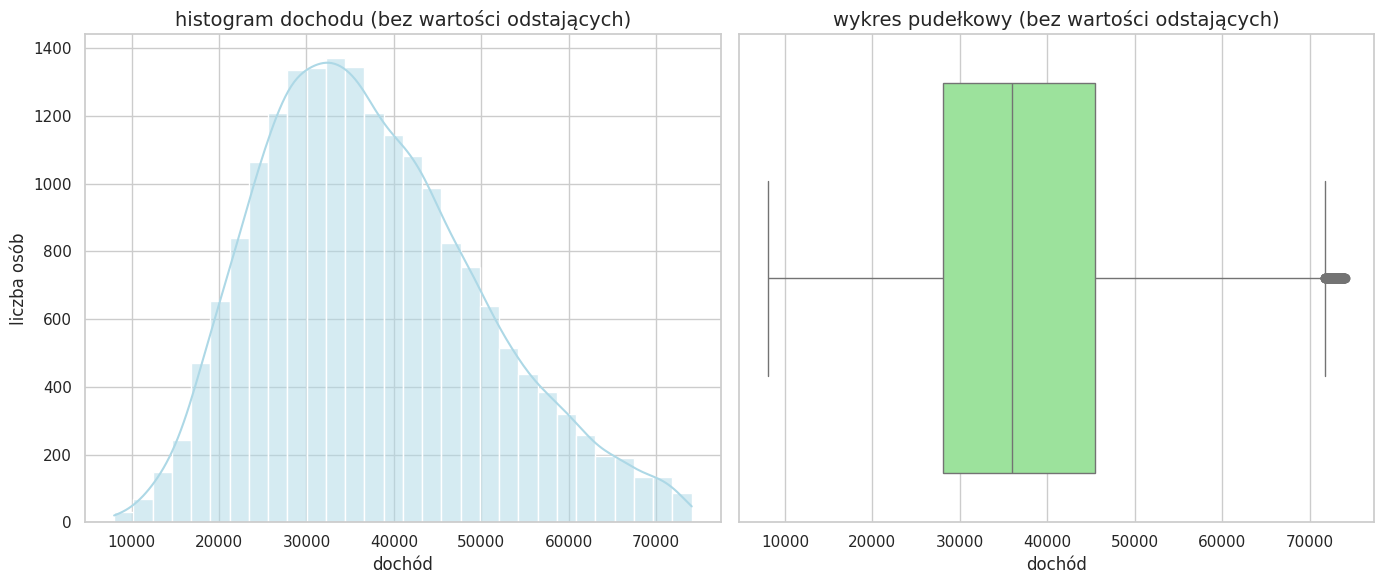

In [ ]:
df_oczyszczone = df[(df["Income"] >= granica_dolna) & (df["Income"] <= granica_gorna)]
sns.set(style="whitegrid")
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.histplot(df_oczyszczone["Income"], kde=True, color="lightblue", bins=30)
plt.title("histogram dochodu (bez wartości odstających)", fontsize=14)
plt.xlabel("dochód", fontsize=12)
plt.ylabel("liczba osób", fontsize=12)
plt.subplot(1, 2, 2)
sns.boxplot(x=df_oczyszczone["Income"], color="lightgreen")
plt.title("wykres pudełkowy (bez wartości odstających)", fontsize=14)
plt.xlabel("dochód", fontsize=12)
plt.tight_layout()
plt.show()

Parametry metody:
* **Kwartyl 1 (Q1):** 28 233.04
* **Kwartyl 3 (Q3):** 46 604.81
* **IQR:** 18 371.77
* **Dolna granica (Q1 - 1.5*IQR):** 675.38
* **Górna granica (Q3 + 1.5*IQR):** 74 162.47

Skąd te obliczenia?

W idealnym, symetrycznym przypadku (rozkład normalny):

Q1 (pierwszy kwartyl) znajduje się w odległości -0.67 odchylenia standardowego ($\sigma$) od średniej.
Q3 (trzeci kwartyl) znajduje się w odległości +0.67 odchylenia standardowego ($\sigma$) od średniej.
IQR (rozstęp między nimi) wynosi więc około 1.35$\sigma$. Jeśli podstawimy te liczby do wzoru na górną granicę ($Q3 + 1.5 \times IQR$), otrzymamy:$$0.67\sigma + (1.5 \times 1.35\sigma) \approx 0.67\sigma + 2.02\sigma \approx \mathbf{2.7\sigma}$$ W statystyce granica 2.7 odchylenia standardowego ($2.7\sigma$) jest bardzo ważna. Obejmuje ona 99.3% wszystkich przypadków. Tylko 0.7% danych znajduje się poza tą granicą.

W zbiorze zidentyfikowane zostały **571 obserwacje odstające**.

Wpływ wartości odstających na statystyki:

1.  **Średnia:** Po usunięciu ekstremów średnia spadła z **40 016** do **37 428**. Wartości odstające zawyżały przeciętny dochód o ponad 2 500 jednostek.
2.  **Odchylenie standardowe:** Spadek z **23 782** do **12 666**. Oznacza to, że po usunięciu odstających dane są znacznie bardziej skupione wokół średniej, co sprzyja lepszemu dopasowaniu modeli liniowych.
3.  **Wartość maksymalna:** Zredukowana z ekstremalnych **541 028** do **74 057**.


##4. Przygotuj dane do modelowania regresyjnego:
   - zakoduj zmienne kategoryczne (np. one-hot encoding),
   - podziel dane na `X` (cechy) oraz `y` = `Income`,
   - podziel dane na zbiór treningowy i testowy (80/20),
   - wykonaj standaryzację cech numerycznych.

In [ ]:
X = df.drop(columns=["Income", "Income_Outlier", "Potential_Savings"])
y = df["Income"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
zmienne_kategoryczne = ["Education", "Sector", "Marital_Status"]
zmienne_numeryczne = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
print(zmienne_kategoryczne)
print(zmienne_numeryczne)

['Education', 'Sector', 'Marital_Status']
['Age', 'City_Tier', 'Dependents', 'Rent', 'Groceries', 'Transport', 'Healthcare', 'Entertainment', 'Loan_Repayment', 'Savings_Goal']


In [ ]:
prep = ColumnTransformer(transformers=[("num", StandardScaler(), zmienne_numeryczne),("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), zmienne_kategoryczne) ])

In [ ]:
X_train_transf = prep.fit_transform(X_train)
X_test_transf = prep.transform(X_test)

In [ ]:
X_train_transf = prep.fit_transform(X_train)
print(f"liczba kolumn przed: {X.shape[1]}")
print(f"liczba kolumn po transformacji: {X_train_transf.shape[1]}")

liczba kolumn przed: 13
liczba kolumn po transformacji: 19


Z procesu modelowania usunęłam zmienną `Potential_Savings`.
Zmienna ta jest bezpośrednio matematycznie powiązana z `Income` (Dochód = Wydatki + Oszczędności). Jej pozostawienie spowodowałoby  **wyciek danych**, przez co model "oszukiwałby", zamiast uczyć się rzeczywistych wzorców.

Transformacja danych:
*  **Kodowanie zmiennych kategorycznych:**
    * Zmienne tekstowe (`Education`, `Sector`, `Marital_Status`) zamienione zostały na kolumny binarne (0/1).
    * Użyłam parametru `drop='first'`, usuwając pierwszą kategorię z każdej cechy, aby uniknąć współliniowości (redundancji informacji).
*  **Podział zbioru danych:**
    * Dane podzielone zostały w proporcji **80% (trening)** do **20% (test)**.
*  **Standaryzacja:**
    * Cechy numeryczne (np. `Age`, `Rent`) zostały przeskalowane, aby miały średnią 0 i odchylenie standardowe 1 (zgodnie z parametrami dla standardowego rozkładu normalnego). Zapobiega to dominacji zmiennych o dużych wartościach (np. czynsz) nad zmiennymi o małych wartościach (np. wiek).

##5. Zbuduj i oceń dwa modele regresyjne:
   - model 1: regresja liniowa na danych bez dodatkowych operacji na odstających,
   - model 2: regresja liniowa na danych po obsłudze odstających (usunięcie/przycięcie lub transformacja `log1p` zmiennej `Income`).
   - porównaj wyniki modeli metrykami `RMSE` oraz `R2`.

In [ ]:
def train_and_evaluate(data, title):
  X = data.drop(columns=["Income", "Income_Outlier", "Potential_Savings"])
  y = data["Income"]
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
  model = Pipeline(steps=[("preprocessor", prep),("regressor", LinearRegression())])
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  rmse = np.sqrt(mean_squared_error(y_test, y_pred))
  r2 = r2_score(y_test, y_pred)
  print(f"RMSE: {rmse:.2f}")
  print(f"R^2: {r2:.4f}\n")
  return rmse, r2

In [ ]:
rmse1, r21 = train_and_evaluate(df, "model 1 (z odstajacymi)")

RMSE: 18601.87
R^2: 0.3889



In [ ]:
df_oczyszczone = df[df["Income_Outlier"] == 0]
rmse2, r22 = train_and_evaluate(df_oczyszczone, "model 1 (z odstajacymi)")

RMSE: 4561.58
R^2: 0.8735



In [ ]:
wyniki = pd.DataFrame({"metryka": ["RMSE", "R^2"],"model 1 (z odstajacymi)": [rmse1, r21], "model 2 (bez odstajcych)": [rmse2, r22]})
wyniki

,metryka,model 1 (z odstajacymi),model 2 (bez odstajcych)
0,RMSE,18601.865980,4561.575844
1,R^2,0.388912,0.873480


W celu zbadania wpływu wartości odstających na jakość predykcji, zbudowałam i porównałam dwa modele regresji liniowej. W obu przypadkach zmienną objaśnianą (y) był `Income`, a ze zbioru cech usunęłam zmienną `Potential_Savings`, aby wycieku danych.

Wyniki eksperymentu:

| Metryka | Model 1 (Dane surowe) | Model 2 (Dane oczyszczone) | Interpretacja |
| :--- | :--- | :--- | :--- |
| **RMSE** | ~18 600 | ~4 500 | **Spadek błędu o ok. 75%**. Model bez odstających myli się średnio o znacznie mniejszą kwotę. |
| **R²** | ~0.39 | ~0.87 | **Wzrost dopasowania**. Model 2 wyjaśnia aż 87% zmienności dochodów, podczas gdy Model 1 radził sobie słabo (39%). |

Przy obliczaniu RMSE korzystamy ze wzoru: $$RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2},$$
Natomiast przy $R^2$ korzystamy z
$$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$
Wnioski:
*  Regresja liniowa okazała się bardzo wrażliwa na wartości odstające. Obecność rekordów z dochodami powyżej 75 000 (sięgającymi 500 000) całkowicie zaburzyła linię regresji, próbując dopasować się do ekstremów kosztem większości danych.
* Usunięcie obserwacji zidentyfikowanych metodą IQR pozwoliło na znaczną poprawę jakości modelu.


##6. Podsumuj wyniki:
   - opisz, jak wartości odstające wpływały na `Income` i jakość modelu,
   - wskaż, który wariant obsługi odstających dał lepsze wyniki i dlaczego.

Analiza przeprowadzona w ramach projektu pozwoliła na zbadanie wpływu wartości odstających (outliers) na statystyki opisowe oraz jakość modeli predykcyjnych.

Jak wartości odstające wpływały na `Income` i jakość modelu?

* **Wpływ na statystyki:**
    Obecność wartości odstających drastycznie zaburzała obraz danych. Średnia zarobków w pełnym zbiorze wynosiła **40 017**, podczas gdy po usunięciu ekstremów spadła do **37 429**. Jeszcze bardziej widoczne było to w odchyleniu standardowym, które zmalało prawie dwukrotnie (z 23 782 do 12 666). Oznacza to, że nieliczna grupa osób z bardzo wysokimi dochodami (powyżej 75 000, sięgającymi nawet 500 000) sztucznie zawyżała parametry populacji.

* **Wpływ na model (Model 1):**
    Model trenowany na danych z wartościami odstającymi radził sobie słabo.
    * **RMSE (18 601.87):** Błąd prognozy był ogromny. Model mylił się średnio o ponad 18 tysięcy jednostek.
    * **R^2 (0.39):** Model wyjaśniał jedynie 39% zmienności dochodów.
    Przyczyną tak słabych wyników jest fakt, że regresja liniowa jest bardzo wrażliwa na punkty oddalone. Algorytm na siłę próbował dopasować linię trendu do milionerów, przez co tracił precyzję dla zwykłych obserwacji.

Który wariant obsługi odstających dał lepsze wyniki i dlaczego?

Zdecydowanie lepsze wyniki osiągnął **Model 2**, trenowany na danych po usunięciu wartości odstających metodą IQR.

* **RMSE (4 561.58):** Błąd spadł ponad czterokrotnie.
* **R^2 (0.87):** Dopasowanie modelu wzrosło do poziomu 87%.

Dlaczego Model 2 jest lepszy?

Usunięcie  najbardziej skrajnych obserwacji pozwoliło algorytmowi skupić się na głównym nurcie danych. Dzięki temu relacje między cechami (np. wiek, wykształcenie, wydatki) a dochodem stały się wyraźniejsze i bardziej przewidywalne. Model przestał być rozciągany przez ekstrema i mógł precyzyjnie zamodelować typowe zarobki.
